### 시각화 실습 

- matplotlib, seaborn, plotly를 사용하여 시각화 
- matplotlib : 그래프 기본 도구 
- seaborn : 분포, 상관관계 같은 통계 그래프를 쉽게 만들어 줌 
- plotly : 마우스로 확대, 축소, 값 확인이 가능한 대화형 그래프를 만들어 줌 

In [1]:
# 필요한 라이브러리 읽어 오기 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go 

In [2]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
data_path = r"C:\Users\user\Desktop\python_campus\dev\data\raw\manufacturing_datetime_raw.csv"

df = pd.read_csv(data_path)

df.head()

,record_id,timestamp_text,machine_id,temperature,pressure,speed,humidity,vibration,current,process_start_text,process_end_text
0,1,2026-07-14 08:00:00,M01,67.84,5.46,1584.7,32.24,1.61,13.65,2026-07-14 08:00:05,2026-07-14 08:00:54
1,2,2026-07-14 08:02:00,M01,70.74,5.19,1423.2,46.40,2.55,13.58,2026-07-14 08:02:05,2026-07-14 08:03:28
2,3,2026-07-14 08:04:00,M01,73.87,4.90,1533.2,37.21,2.60,13.44,2026-07-14 08:04:05,2026-07-14 08:05:10
3,4,2026-07-14 08:06:00,M01,71.26,4.96,1610.0,41.23,2.01,13.08,2026-07-14 08:06:05,2026-07-14 08:07:31
4,5,2026-07-14 08:08:00,M01,73.46,5.34,1538.8,52.71,2.02,12.89,2026-07-14 08:08:05,2026-07-14 08:09:08


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           180 non-null    int64  
 1   timestamp_text      179 non-null    str    
 2   machine_id          180 non-null    str    
 3   temperature         178 non-null    float64
 4   pressure            178 non-null    float64
 5   speed               180 non-null    float64
 6   humidity            180 non-null    float64
 7   vibration           180 non-null    float64
 8   current             180 non-null    float64
 9   process_start_text  180 non-null    str    
 10  process_end_text    180 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 15.6 KB


In [5]:
clean_df = df.copy()
clean_df["timestamp"] = pd.to_datetime(
    clean_df["timestamp_text"],
    errors = "coerce"
)
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   record_id           180 non-null    int64         
 1   timestamp_text      179 non-null    str           
 2   machine_id          180 non-null    str           
 3   temperature         178 non-null    float64       
 4   pressure            178 non-null    float64       
 5   speed               180 non-null    float64       
 6   humidity            180 non-null    float64       
 7   vibration           180 non-null    float64       
 8   current             180 non-null    float64       
 9   process_start_text  180 non-null    str           
 10  process_end_text    180 non-null    str           
 11  timestamp           177 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(6), int64(1), str(4)
memory usage: 17.0 KB


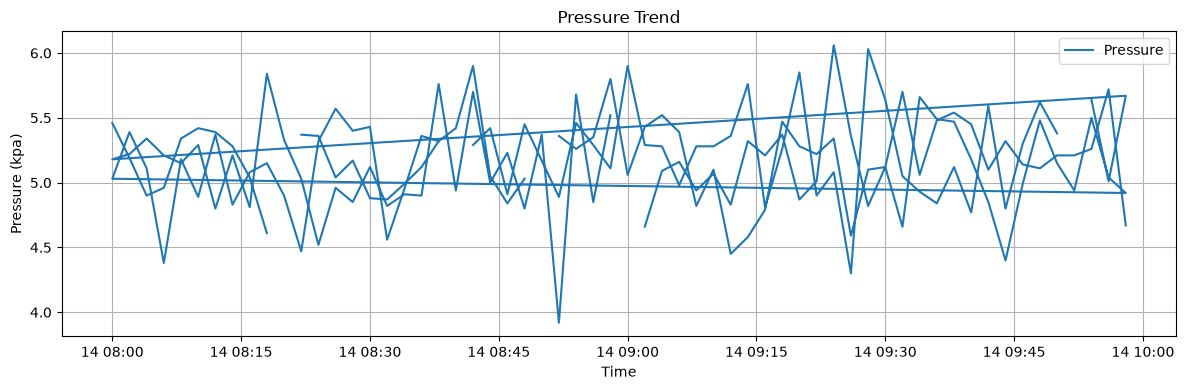

In [6]:
# matplotlib 온도 선 그래프 그려보기 

plt.figure(figsize=(12,4))

plt.plot(
    clean_df["timestamp"], # x축
    clean_df["pressure"], # y축
    label = "Pressure"
)

plt.title("Pressure Trend")
plt.xlabel("Time")
plt.ylabel("Pressure (kpa)")
plt.legend() # 표 내에 라벨을 분리 표시 
plt.grid(True) # 그래프 내에 그리드 표시 
# plt.xticks(rotation=45) # x축의 눈금 표시 값을 45도 기울임 
plt.tight_layout()
plt.show()

In [7]:
# seaborn 시각화 

# histogram 히스토그램 : 값이 어느 구간에 많이 모여 있는지 확인 (분포)
# 박스 플롯 : 중앙값과 이상치 확인 
# 산점도 : 두 센서 값 사이 (x축과 y축) 관계 확인 
# 히트맵 : 여러 센서의 상관관계 확인 (컬럼)

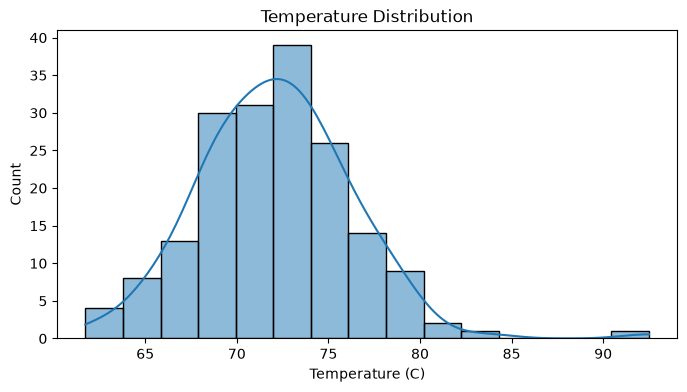

In [8]:
plt.figure(figsize=(8,4))

sns.histplot (
    data = clean_df,
    x = "temperature",
    bins = 15,
    kde = True, # kernel desity estimation 분포함수 
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (C)")
plt.show()

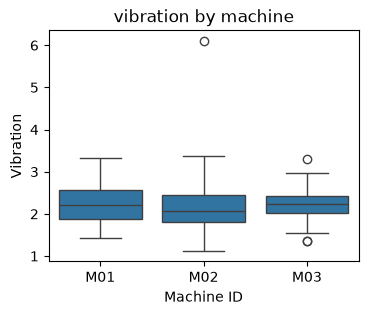

In [9]:
# box plot 그리기 

plt.figure(figsize=(4,3))

sns.boxplot(
    data = clean_df,
    x = "machine_id",
    y = "vibration",
)

plt.title("vibration by machine")
plt.xlabel("Machine ID")
plt.ylabel("Vibration")
plt.show()

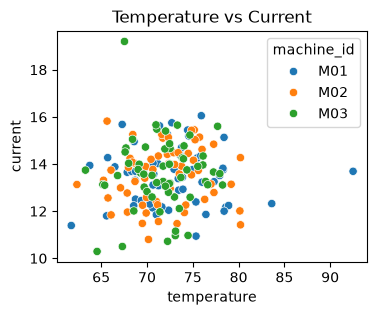

In [10]:
# scatter plot 그리기

plt.figure(figsize=(4,3))

sns.scatterplot(
    data = clean_df,
    x = "temperature",
    y = "current",
    hue = "machine_id",
)

plt.title("Temperature vs Current")
plt.show()

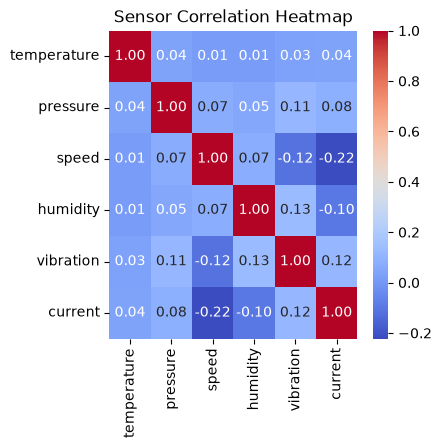

In [11]:
# 히트맵 : 센서 변수 사이의 상관 관계를 확인 

# 상관계수는 0-1, 1일수록 일치함 
correlation_df = clean_df[['temperature', 'pressure',
       'speed', 'humidity', 'vibration', 'current']].corr() # 각 컬럼들 끼리의 상관계수를 구함 

plt.figure(figsize=(4,4))

sns.heatmap(
    correlation_df,
    annot = True, # 숫자 상관관계값을 표시하겠다는 것 
    fmt = ".2f", # 포맷 소수점 둘째자리까지 
    cmap = "coolwarm" # colormap 히트맵 표시 컬러 팔레트 
)

plt.title("Sensor Correlation Heatmap")
plt.show()

In [12]:
clean_df.columns

Index(['record_id', 'timestamp_text', 'machine_id', 'temperature', 'pressure',
       'speed', 'humidity', 'vibration', 'current', 'process_start_text',
       'process_end_text', 'timestamp'],
      dtype='str')

In [17]:
# plotly 대화형 그래프 만들기 

temperature_fig = px.line(
    clean_df,
    x = "timestamp",
    y = "temperature",
    color = "machine_id", 
    title = "Interactive Temperature Trend",
    markers = True, # 데이터 값이 있는 곳에 실제 데이터 값을 표시해줌 
)

temperature_fig.show()

In [14]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [16]:
# plot 산점도 만들기

scatter_fig = px.scatter(
    clean_df,
    x = "temperature",
    y = "vibration",
    color = "machine_id",
    hover_data = ["pressure", "current", "speed"],
    title = "Temperature and Vibration by machine_id"
)

scatter_fig.show()